In [15]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from src.data.eda import load_processed_dataset
from src.data.io import load_mask
from src.training.train import load_trained_pipeline
from src.evaluation.regression import (
    compute_global_regression_metrics,
    compute_pixel_regression_metrics,
    summarize_pixel_metrics,
    rank_best_and_worst_pixels,
    build_prediction_dataframe,
    build_pixel_timeseries_dataframe,
)

In [16]:
MAIN_DIR = Path("/home/dani/github/profecia/data")

PROCESSED_BASE_DIR = MAIN_DIR / "processed"
SPLITS_BASE_DIR = MAIN_DIR / "splits"
MODELS_BASE_DIR = MAIN_DIR / "models"
MASKS_DIR = MAIN_DIR / "masks"

VARIABLE_NAMES = ["LAI", "SM1", "SM2", "TP", "T2M", "SSRD", "VPD"]

processed_run_name = "land_ebf_bs_annual"
split_mask_name = "landcover"      # "climate" o "landcover"
model_run_name = "rf_baseline"

PROCESSED_DIR = PROCESSED_BASE_DIR / processed_run_name
INPUT_DIR = SPLITS_BASE_DIR / processed_run_name / split_mask_name
MODEL_DIR = MODELS_BASE_DIR / processed_run_name / split_mask_name

print("PROCESSED_DIR:", PROCESSED_DIR)
print("INPUT_DIR:", INPUT_DIR)
print("MODEL_DIR:", MODEL_DIR)

PROCESSED_DIR: /home/dani/github/profecia/data/processed/land_ebf_bs_annual
INPUT_DIR: /home/dani/github/profecia/data/splits/land_ebf_bs_annual/landcover
MODEL_DIR: /home/dani/github/profecia/data/models/land_ebf_bs_annual/landcover


In [17]:
with open(MASKS_DIR / "mask_metadata.json", "r", encoding="utf-8") as f:
    mask_metadata = json.load(f)

macro_labels = {int(k): v for k, v in mask_metadata["masks"]["climate"]["labels"].items()}
lc_labels = {int(k): v for k, v in mask_metadata["masks"]["landcover"]["labels"].items()}

print("macro_labels:", macro_labels)
print("lc_labels:", lc_labels)

macro_labels: {0: 'NoData', 1: 'Tropical', 2: 'Arid', 3: 'Temperate', 4: 'Cold', 5: 'Polar'}
lc_labels: {0: 'NoData', 10: 'Cropland', 20: 'Forest', 30: 'Grassland', 40: 'Shrubland', 70: 'Tundra', 90: 'Barren land', 100: 'Snow/Ice'}


## Cargar dataset procesado para grid y LAI

In [18]:
data_dict, metadata = load_processed_dataset(
    input_dir=PROCESSED_DIR,
    variable_names=VARIABLE_NAMES,
    reference_variable="LAI",
)

lai = data_dict["LAI"]

print("Shape LAI:", lai.shape)
print("Dims LAI:", lai.dims)
print("Periodo:", str(lai.time.min().values)[:10], "->", str(lai.time.max().values)[:10])

Shape LAI: (41, 360, 720)
Dims LAI: ('time', 'latitude', 'longitude')
Periodo: 1982-01-01 -> 2022-01-01


## Cargar arrays de test

In [19]:
X_test = np.load(INPUT_DIR / "X_test.npy", mmap_mode="r")
y_test = np.load(INPUT_DIR / "y_test.npy", mmap_mode="r")

pixel_id_test = np.load(INPUT_DIR / "pixel_id_test.npy", mmap_mode="r")
lat_idx_test = np.load(INPUT_DIR / "lat_idx_test.npy", mmap_mode="r")
lon_idx_test = np.load(INPUT_DIR / "lon_idx_test.npy", mmap_mode="r")
time_idx_test = np.load(INPUT_DIR / "time_idx_test.npy", mmap_mode="r")

with open(INPUT_DIR / "dataset_metadata.json", "r", encoding="utf-8") as f:
    dataset_metadata = json.load(f)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("pixel_id_test:", pixel_id_test.shape)
print("time_idx_test:", time_idx_test.shape)

X_test: (59819, 6)
y_test: (59819,)
pixel_id_test: (59819,)
time_idx_test: (59819,)


## Cargar modelo y scaler

In [20]:
train_info_path = MODEL_DIR / f"{model_run_name}_train_info.json"

with open(train_info_path, "r", encoding="utf-8") as f:
    train_info = json.load(f)

model, scaler = load_trained_pipeline(
    model_path=train_info["model_path"],
    scaler_path=train_info["scaler_path"],
)

print("Modelo:", type(model))
print("Scaler:", type(scaler) if scaler is not None else None)

Modelo: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Scaler: None


## Transformar test si procede y predecir

In [21]:
if scaler is not None:
    X_test_used = scaler.transform(X_test)
    X_test_used = X_test_used.astype(np.float32, copy=False)
else:
    X_test_used = X_test

y_pred_test = model.predict(X_test_used)

print("y_pred_test:", y_pred_test.shape)

y_pred_test: (59819,)


## Métricas globales

In [22]:
global_metrics = compute_global_regression_metrics(
    y_true=y_test,
    y_pred=y_pred_test,
)

global_metrics

{'r2': 0.8351440090098428,
 'rmse': 0.35533592599052927,
 'mae': 0.2420123978897164,
 'n_samples': 59819}

## DataFrame fila a fila y métricas por píxel

In [23]:
prediction_df = build_prediction_dataframe(
    y_true=y_test,
    y_pred=y_pred_test,
    pixel_id=pixel_id_test,
    lat_idx=lat_idx_test,
    lon_idx=lon_idx_test,
    time_idx=time_idx_test,
    latitude_values=lai.latitude.values,
    longitude_values=lai.longitude.values,
    time_values=pd.to_datetime(dataset_metadata["time_values"]),
)

pixel_metrics_df = compute_pixel_regression_metrics(
    y_true=y_test,
    y_pred=y_pred_test,
    pixel_id=pixel_id_test,
    lat_idx=lat_idx_test,
    lon_idx=lon_idx_test,
    latitude=lai.latitude.values[lat_idx_test],
    longitude=lai.longitude.values[lon_idx_test],
)

pixel_metrics_summary = summarize_pixel_metrics(pixel_metrics_df)

display(pixel_metrics_df.head())
pixel_metrics_summary

,pixel_id,n_samples,r2,rmse,mae,y_true_variance,lat_idx,lon_idx,latitude,longitude
0,52777,41,-114.986634,0.544028,0.522721,0.002552,73,217,-53.5,-71.5
1,53493,41,-40866.652557,0.512309,0.508901,0.000006,74,213,-53.0,-73.5
2,54962,41,-56.264508,0.461349,0.422044,0.003717,76,242,-52.0,-59.0
3,54963,41,-203.894916,0.641705,0.599594,0.002010,76,243,-52.0,-58.5
4,58542,41,-9.738113,0.062645,0.045650,0.000365,81,222,-49.5,-69.0


{'n_pixels': 1459,
 'n_pixels_valid_r2': 1458,
 'n_pixels_nan_r2': 1,
 'r2_mean': -1337.7598480383294,
 'r2_median': -8.111770384339879,
 'r2_p05': -236.48585649398538,
 'r2_p95': -0.27633639555022843,
 'rmse_mean': 0.27464290784003237,
 'rmse_median': 0.2158811416567303,
 'mae_mean': 0.2420123978897164,
 'mae_median': 0.17900757420692265,
 'y_true_variance_mean': 0.00895892178358848,
 'y_true_variance_median': 0.005338715855032206}

## Añadir climate y landcover a métricas por píxel

In [24]:
climate_mask = load_mask(
    mask_dir=MASKS_DIR,
    mask_name="climate",
    latitude=lai.latitude.values,
    longitude=lai.longitude.values,
)

landcover_mask = load_mask(
    mask_dir=MASKS_DIR,
    mask_name="landcover",
    latitude=lai.latitude.values,
    longitude=lai.longitude.values,
)

pixel_metrics_df["climate_code"] = [
    int(climate_mask.values[int(i), int(j)])
    for i, j in zip(pixel_metrics_df["lat_idx"], pixel_metrics_df["lon_idx"])
]
pixel_metrics_df["climate_label"] = pixel_metrics_df["climate_code"].map(macro_labels)

pixel_metrics_df["landcover_code"] = [
    int(landcover_mask.values[int(i), int(j)])
    for i, j in zip(pixel_metrics_df["lat_idx"], pixel_metrics_df["lon_idx"])
]
pixel_metrics_df["landcover_label"] = pixel_metrics_df["landcover_code"].map(lc_labels)

display(pixel_metrics_df.head())

,pixel_id,n_samples,r2,rmse,mae,y_true_variance,lat_idx,lon_idx,latitude,longitude,climate_code,climate_label,landcover_code,landcover_label
0,52777,41,-114.986634,0.544028,0.522721,0.002552,73,217,-53.5,-71.5,29,NaN,30,Grassland
1,53493,41,-40866.652557,0.512309,0.508901,0.000006,74,213,-53.0,-73.5,29,NaN,30,Grassland
2,54962,41,-56.264508,0.461349,0.422044,0.003717,76,242,-52.0,-59.0,29,NaN,30,Grassland
3,54963,41,-203.894916,0.641705,0.599594,0.002010,76,243,-52.0,-58.5,29,NaN,30,Grassland
4,58542,41,-9.738113,0.062645,0.045650,0.000365,81,222,-49.5,-69.0,5,Polar,90,Barren land


## Mejores y peores 4 píxeles por R²

In [25]:
rank_r2 = rank_best_and_worst_pixels(
    pixel_metrics_df,
    metric="r2",
    top_k=4,
)

best_pixels_r2 = rank_r2["best"].copy()
worst_pixels_r2 = rank_r2["worst"].copy()

print("=== BEST PIXELS (R2) ===")
display(best_pixels_r2)

print("=== WORST PIXELS (R2) ===")
display(worst_pixels_r2)

=== BEST PIXELS (R2) ===


,pixel_id,n_samples,r2,rmse,mae,y_true_variance,lat_idx,lon_idx,latitude,longitude,climate_code,climate_label,landcover_code,landcover_label
0,99960,41,0.465942,0.045833,0.036677,0.003933,138,600,-21.0,120.0,4,Cold,90,Barren land
1,97084,41,0.465006,0.040004,0.031706,0.002991,134,604,-23.0,122.0,4,Cold,90,Barren land
2,85576,41,0.452366,0.099640,0.089091,0.018129,118,616,-31.0,128.0,4,Cold,90,Barren land
3,96173,41,0.446941,0.088416,0.069295,0.014135,133,413,-23.5,26.5,6,NaN,40,Shrubland


=== WORST PIXELS (R2) ===


,pixel_id,n_samples,r2,rmse,mae,y_true_variance,lat_idx,lon_idx,latitude,longitude,climate_code,climate_label,landcover_code,landcover_label
0,129449,41,-1.063231e+06,1.247543,1.162236,0.000001,179,569,-0.5,104.5,1,Tropical,20,Forest
1,217714,41,-2.793577e+05,0.920420,0.895140,0.000003,302,274,61.0,-43.0,29,NaN,100,Snow/Ice
2,142763,41,-1.793104e+05,1.414996,1.410948,0.000011,198,203,9.0,-78.5,2,Arid,20,Forest
3,141714,41,-1.306586e+05,0.710897,0.699502,0.000004,196,594,8.0,117.0,2,Arid,20,Forest


## Density scatter de los 4 mejores y 4 peores

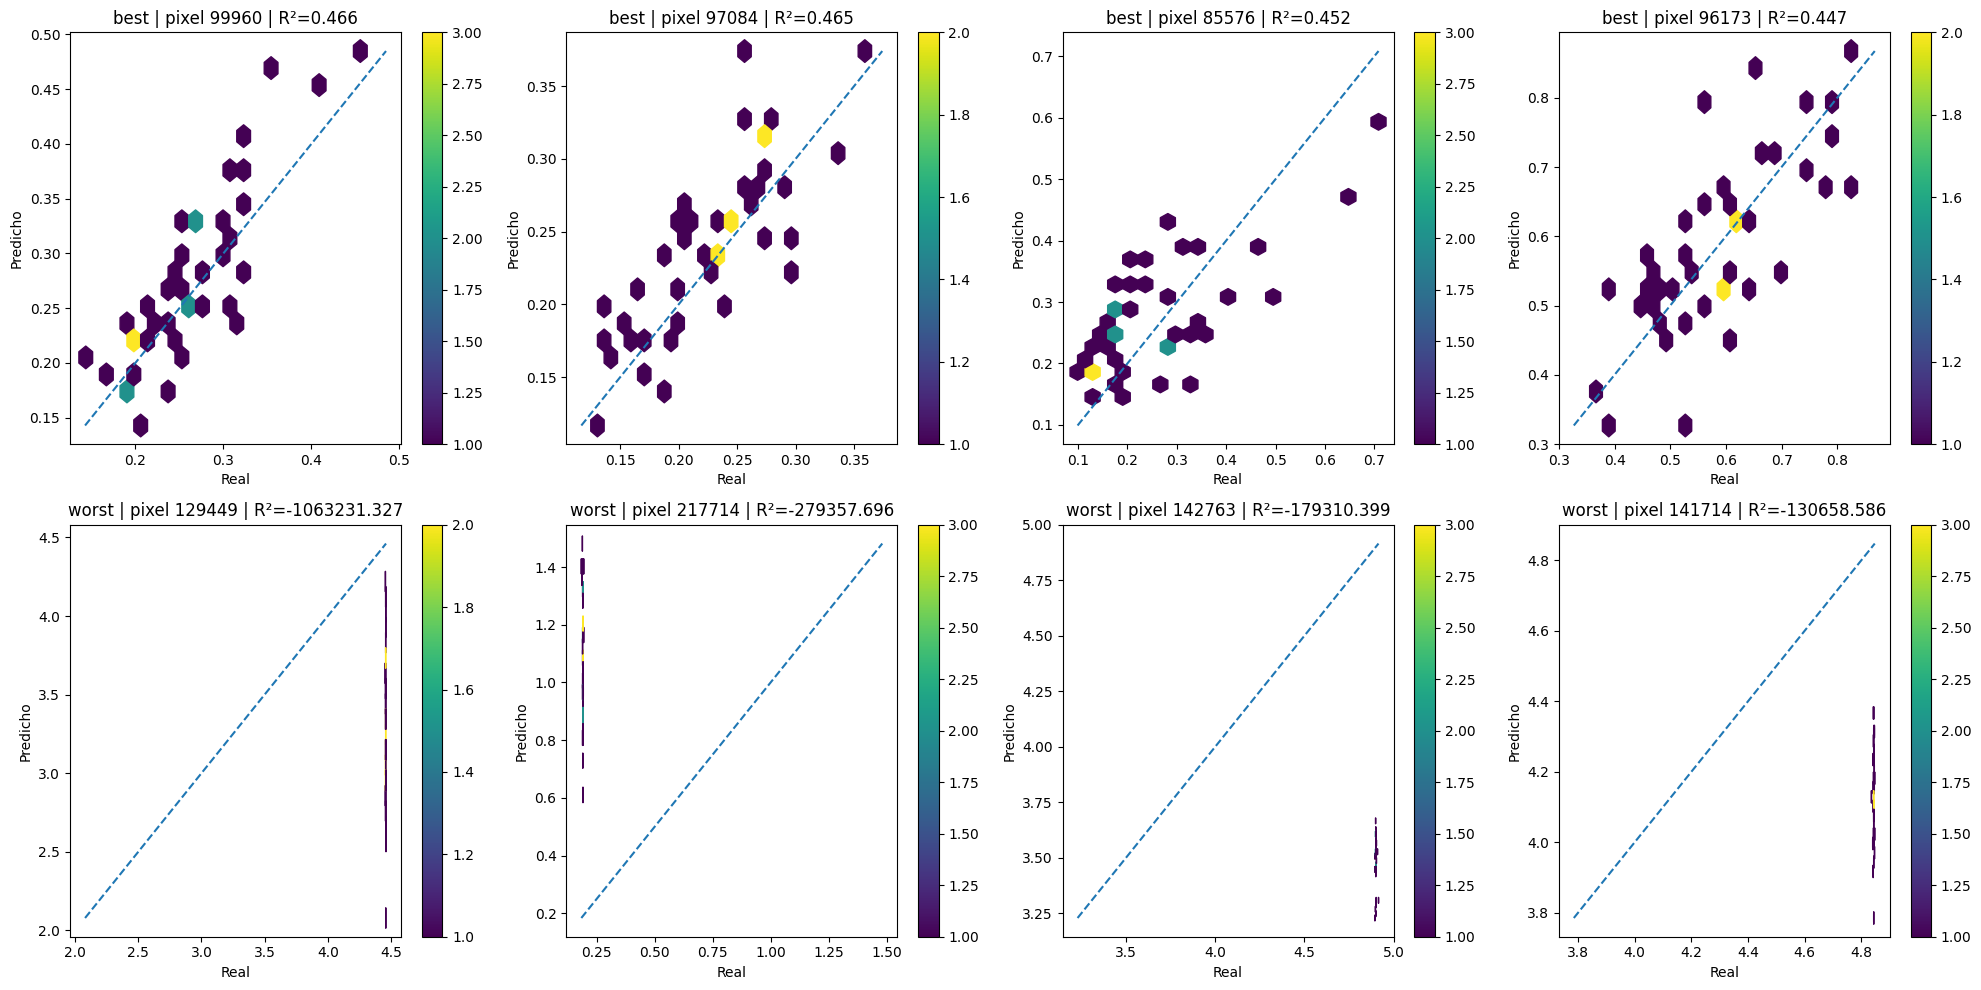

In [26]:
selected_pixels = pd.concat(
    [
        best_pixels_r2.assign(group="best"),
        worst_pixels_r2.assign(group="worst"),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for ax, (_, row) in zip(axes, selected_pixels.iterrows()):
    pid = int(row["pixel_id"])
    ts_df = build_pixel_timeseries_dataframe(prediction_df, pixel_id=pid)

    if len(ts_df) >= 20:
        hb = ax.hexbin(
            ts_df["y_true"].values,
            ts_df["y_pred"].values,
            gridsize=20,
            mincnt=1,
        )
        plt.colorbar(hb, ax=ax)
    else:
        ax.scatter(ts_df["y_true"].values, ts_df["y_pred"].values, s=20)

    xy_min = min(ts_df["y_true"].min(), ts_df["y_pred"].min())
    xy_max = max(ts_df["y_true"].max(), ts_df["y_pred"].max())
    ax.plot([xy_min, xy_max], [xy_min, xy_max], linestyle="--")

    ax.set_title(f"{row['group']} | pixel {pid} | R²={row['r2']:.3f}")
    ax.set_xlabel("Real")
    ax.set_ylabel("Predicho")

plt.tight_layout()
plt.show()

## Series temporales real vs predicha

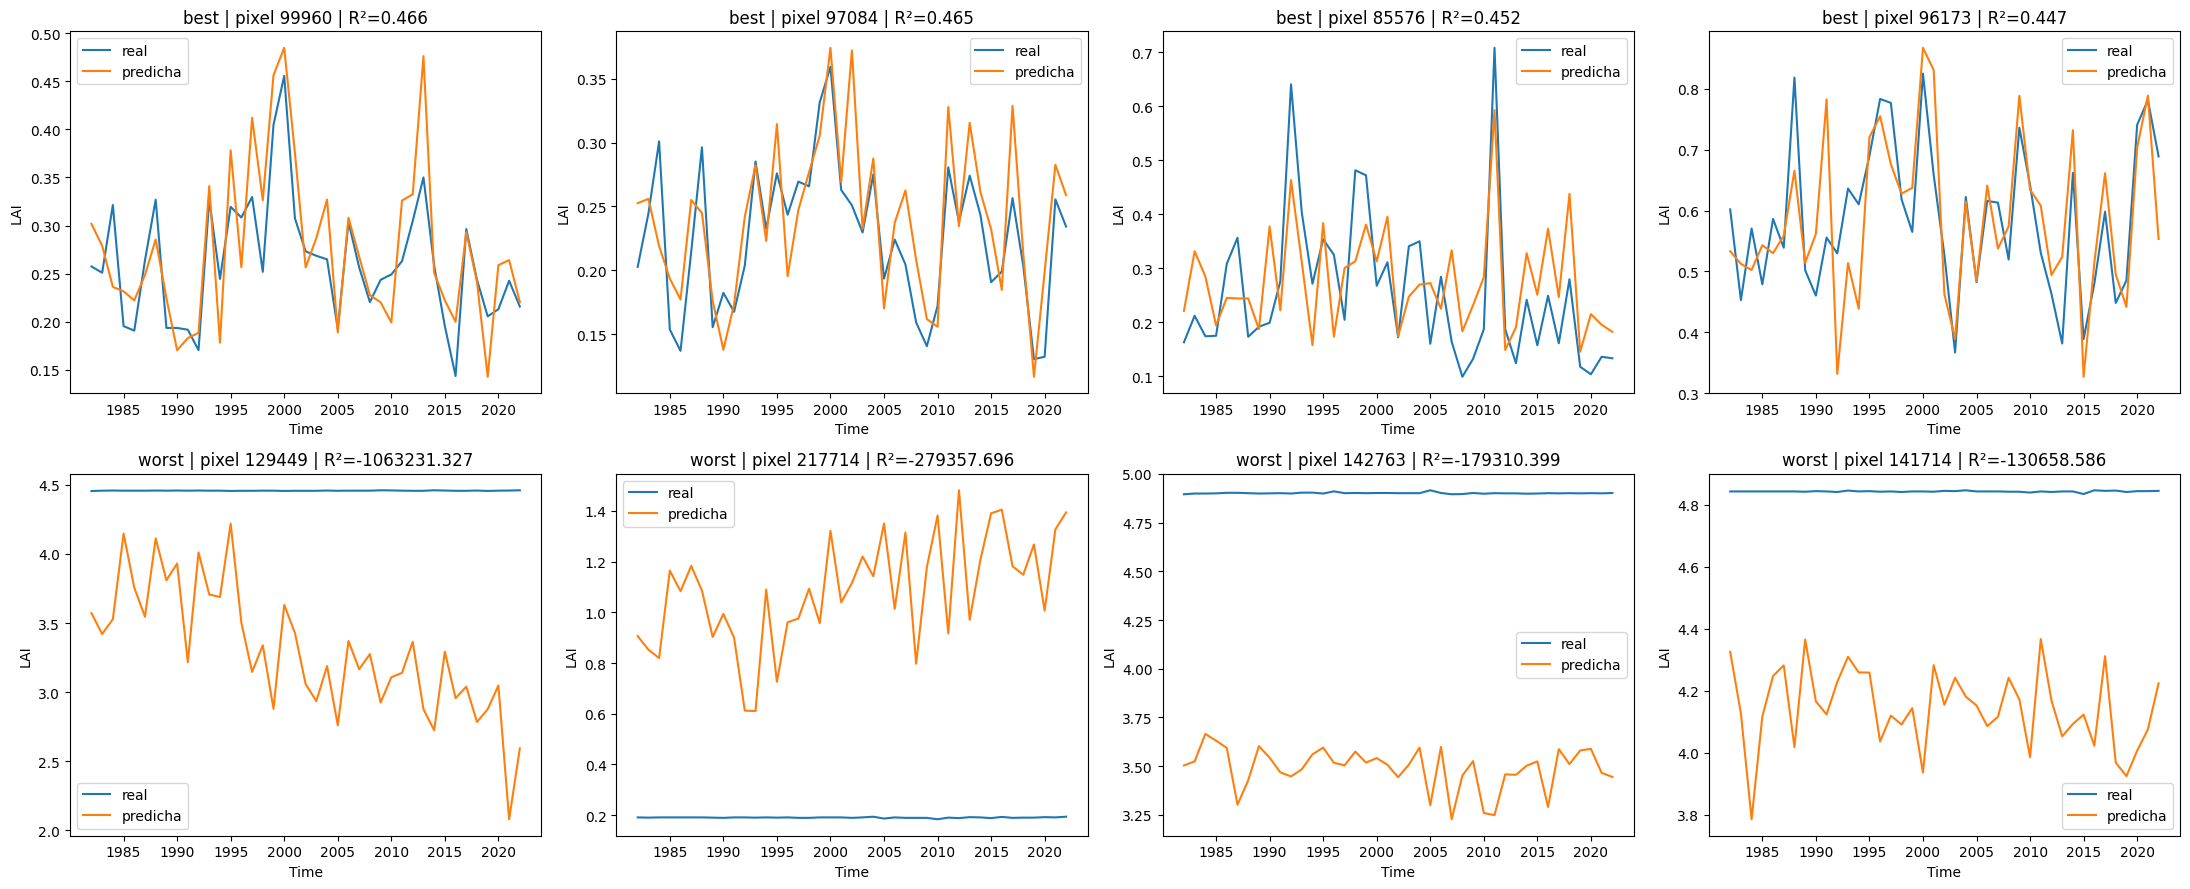

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9), sharex=False)
axes = axes.ravel()

for ax, (_, row) in zip(axes, selected_pixels.iterrows()):
    pid = int(row["pixel_id"])
    ts_df = build_pixel_timeseries_dataframe(prediction_df, pixel_id=pid)

    ax.plot(ts_df["time"], ts_df["y_true"], label="real")
    ax.plot(ts_df["time"], ts_df["y_pred"], label="predicha")
    ax.set_title(f"{row['group']} | pixel {pid} | R²={row['r2']:.3f}")
    ax.set_xlabel("Time")
    ax.set_ylabel("LAI")
    ax.legend()

plt.tight_layout()
plt.show()

## Resumen opcional por climate / landcover

In [28]:
display(
    pixel_metrics_df.groupby("climate_label", dropna=False)[["r2", "rmse", "mae"]]
    .mean(numeric_only=True)
    .sort_values("r2", ascending=False)
)

display(
    pixel_metrics_df.groupby("landcover_label", dropna=False)[["r2", "rmse", "mae"]]
    .mean(numeric_only=True)
    .sort_values("r2", ascending=False)
)

,r2,rmse,mae
climate_label,,,
Polar,-31.420848,0.088456,0.077096
Cold,-44.820802,0.092309,0.076556
Temperate,-47.315815,0.465170,0.417071
NaN,-474.507538,0.263736,0.230711
Arid,-15133.776915,0.677971,0.637743
Tropical,-55277.008373,0.625561,0.575252


,r2,rmse,mae
landcover_label,,,
Shrubland,-17.880132,0.292601,0.253703
Cropland,-23.217230,0.336838,0.290917
Tundra,-39.163977,0.168281,0.148251
Grassland,-168.958233,0.254115,0.220370
Barren land,-792.113502,0.111901,0.097387
Forest,-3363.081225,0.365476,0.328670
Snow/Ice,-22265.311170,0.389125,0.366919
